In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Data/updated dataset.csv")

In [3]:
df.head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag,deadline_date,avg_experience,avg_salary
0,JOB041385,CobaltWealth,MNC,healthtech,146085,Germany,soc analyst,Mid,3.0,5.0,...,98.0,4.0,5.0,5.0,105800.0,128800.0,No,2023-11-12,4.0,117300.0
1,JOB018462,DriftLearn,Mid-size,cloud/infra,5882,USA,mobile engineer (ios),Mid,1.0,4.0,...,134.0,2.0,1.0,0.0,105800.0,128800.0,No,2025-06-29,2.5,117300.0
2,JOB110011,AnchorBuzz Labs,MNC,healthtech,186507,USA,qa engineer,Lead,7.0,15.0,...,36.0,4.0,1.0,1.0,238800.0,274700.0,No,2026-01-24,11.0,256750.0
3,JOB073462,KiteSphere,Unicorn,healthtech,10930,Brazil,research scientist,Entry,1.0,4.0,...,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes,2020-12-09,2.5,100150.0
4,JOB051683,AetherNode Co,MNC,social/adtech,42510,USA,product manager,Senior,6.0,9.0,...,43.0,3.0,1.0,1.0,186800.0,245400.0,Yes,2025-07-19,7.5,216100.0


In [4]:
df.shape

(113807, 31)

# LINEAR REGRESSION

In [5]:
df["avg_salary"]

0         117300.0
1         117300.0
2         256750.0
3         100150.0
4         216100.0
            ...   
113802    234800.0
113803    100500.0
113804    141200.0
113805    165050.0
113806    133700.0
Name: avg_salary, Length: 113807, dtype: float64

In [6]:
df["avg_salary"].isnull().sum()

np.int64(0)

In [8]:
target = 'avg_salary'

I selected avg_salary as the target because it shows the average salary for each job posting. As it is a num value, we can use it for a regression model

In [7]:
X = df.drop(columns=[
    "avg_salary",
    "salary_min_usd",
    "salary_max_usd",
    "layoff_within_12_months_flag"
])

y = df["avg_salary"]

We have drop salary_min_usd and salary_max_usd cols because avg_salary is derived from these cols<br>
layoff_within_12_months_flag col is droped because it is used in further prediction 


In [9]:
df.columns

Index(['job_id', 'company_name', 'company_type', 'sector',
       'company_size_employees', 'hq_country', 'job_role', 'seniority_level',
       'years_experience_min', 'years_experience_max', 'required_tech_stack',
       'primary_programming_language', 'work_mode', 'visa_sponsorship_offered',
       'job_location_country', 'job_location_city', 'salary_currency',
       'posting_date', 'application_deadline', 'date_position_filled',
       'position_status', 'number_of_applicants', 'number_of_interview_rounds',
       'offers_extended', 'offers_accepted', 'salary_min_usd',
       'salary_max_usd', 'layoff_within_12_months_flag', 'deadline_date',
       'avg_experience', 'avg_salary'],
      dtype='str')

In [10]:
X= df[[
    "company_type",
    "sector",
    "job_role",
    "seniority_level",
    "years_experience_min",
    "years_experience_max",
    "work_mode",
    "salary_currency",
    "number_of_interview_rounds",
    "company_size_employees"
    
]].copy()
y= df["avg_salary"]

In [11]:
print(X.shape)
print(y.shape)

(113807, 10)
(113807,)


### ENCODING

In [12]:
seniority_replace= {"Intern":1, "Entry":2, "Mid":3, "Senior":4, "Lead":5, "Principal":6 }
X["seniority_level"]= X["seniority_level"].map(seniority_replace)

We have done ordinal encoding here because there is natural hierarchical order in seniority_level

In [13]:
X= pd.get_dummies( X,columns=["company_type","sector","job_role","work_mode","salary_currency"], drop_first=True, dtype=int)

Here we have done One-Hot Encoding

In [14]:
X.shape

(113807, 61)

In [15]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 113807 entries, 0 to 113806
Data columns (total 61 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   seniority_level                         113807 non-null  int64  
 1   years_experience_min                    113807 non-null  float64
 2   years_experience_max                    113807 non-null  float64
 3   number_of_interview_rounds              113807 non-null  float64
 4   company_size_employees                  113807 non-null  int64  
 5   company_type_MNC                        113807 non-null  int64  
 6   company_type_Mid-size                   113807 non-null  int64  
 7   company_type_Startup                    113807 non-null  int64  
 8   company_type_Unicorn                    113807 non-null  int64  
 9   sector_cloud/infra                      113807 non-null  int64  
 10  sector_crypto/web3                      113807 non-null

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.2, random_state=42)

In [17]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
print(mae)
print(mse)
print(rmse)
print(r2)

23560.940996415036
1937556570.5806274
44017.68474807174
0.5869237452221124


MAE: On average, the predicted salary differs from the actual salary by around 23.6K.<br>
MSE & RMSE: These values show that the model has some noticeable errors<br>
R²: The model is able to explain about 58.7% of the salary variation

In [19]:
print(y_test[:5])
print(y_pred[:5])

47610      37300.0
9093      110200.0
113643     92900.0
94343      79550.0
69840     158250.0
Name: avg_salary, dtype: float64
[ 16747.63212915 122491.94415939 108701.73844178 112170.30869098
 103948.36918811]


In [20]:
print(y_test[:5])
print(y_pred[:5])

47610      37300.0
9093      110200.0
113643     92900.0
94343      79550.0
69840     158250.0
Name: avg_salary, dtype: float64
[ 16747.63212915 122491.94415939 108701.73844178 112170.30869098
 103948.36918811]


In [21]:
print(y.min())
print(y.max())

10300.0
1910150.0


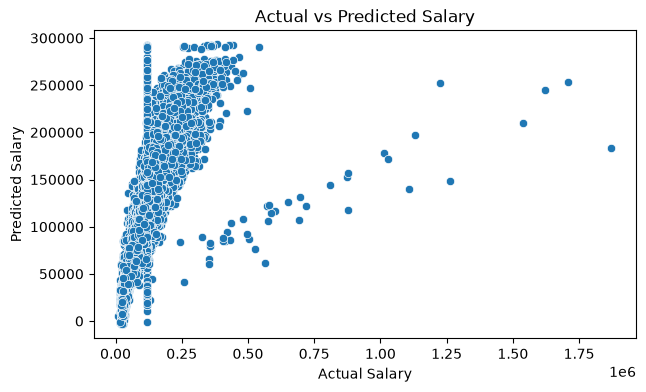

In [22]:
plt.figure(figsize=(7,4))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

The plot shows that actual and predicted salaries have a positive relationship, but the points are quite spread out.
The model predicts lower salaries better, while higher salaries have more noticeable errors.

## CLASSIFICATION

In [23]:
X_layoff = X.copy()

In [24]:
df["layoff_within_12_months_flag"].value_counts()

layoff_within_12_months_flag
No     98884
Yes    14923
Name: count, dtype: int64

In [25]:
df['layoff_target'] = df['layoff_within_12_months_flag'].map({'Yes': 1,'No': 0})

In [26]:
df["layoff_target"].value_counts()

layoff_target
0    98884
1    14923
Name: count, dtype: int64

In [27]:
df["layoff_target"].isnull().sum()

np.int64(0)

In [28]:
print(df['layoff_target'].value_counts(normalize=True) * 100)

layoff_target
0    86.88745
1    13.11255
Name: proportion, dtype: float64


Target classes are imbalanced, so accuracy alone may not be sufficient to evaluate the model

In [29]:
X = df[[
    'company_type',
    'sector',
    'company_size_employees',
    'hq_country',
    'job_role',
    'seniority_level',
    'years_experience_min',
    'years_experience_max',
    'primary_programming_language',
    'work_mode',
    'visa_sponsorship_offered',
    'job_location_country',
    'job_location_city',
    'number_of_interview_rounds'
]]
y = df["layoff_target"]

### ENCODING SOME MORE COLUMNS

In [30]:
encoded_cols = pd.get_dummies(df[[ "hq_country", "primary_programming_language", "visa_sponsorship_offered", "job_location_country", "job_location_city"]], drop_first=True, dtype=int)

In [31]:
X_layoff[encoded_cols.columns]= encoded_cols

In [32]:
X_layoff.info()

<class 'pandas.DataFrame'>
RangeIndex: 113807 entries, 0 to 113806
Columns: 141 entries, seniority_level to job_location_city_unknown
dtypes: float64(3), int64(138)
memory usage: 122.4 MB


In [33]:
print(X_layoff.shape)
print(y.shape)

(113807, 141)
(113807,)


In [34]:
X_layoff.isnull().sum()

seniority_level                0
years_experience_min           0
years_experience_max           0
number_of_interview_rounds     0
company_size_employees         0
                              ..
job_location_city_Tel Aviv     0
job_location_city_Toronto      0
job_location_city_Vancouver    0
job_location_city_Waterloo     0
job_location_city_unknown      0
Length: 141, dtype: int64

In [35]:
X_layoff.head()

,seniority_level,years_experience_min,years_experience_max,number_of_interview_rounds,company_size_employees,company_type_MNC,company_type_Mid-size,company_type_Startup,company_type_Unicorn,sector_cloud/infra,...,job_location_city_San Francisco,job_location_city_Sao Paulo,job_location_city_Seattle,job_location_city_Singapore,job_location_city_Sydney,job_location_city_Tel Aviv,job_location_city_Toronto,job_location_city_Vancouver,job_location_city_Waterloo,job_location_city_unknown
0,3,3.0,5.0,4.0,146085,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,3,1.0,4.0,2.0,5882,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,1
2,5,7.0,15.0,4.0,186507,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,2,1.0,4.0,1.0,10930,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,4,6.0,9.0,3.0,42510,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [36]:
X_layoff_train, X_layoff_test, y_train, y_test = train_test_split(X_layoff, y, test_size=0.20, random_state=42, stratify=y)

In [37]:
X_layoff.dtypes

seniority_level                  int64
years_experience_min           float64
years_experience_max           float64
number_of_interview_rounds     float64
company_size_employees           int64
                                ...   
job_location_city_Tel Aviv       int64
job_location_city_Toronto        int64
job_location_city_Vancouver      int64
job_location_city_Waterloo       int64
job_location_city_unknown        int64
Length: 141, dtype: object

In [38]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_layoff_train_scaled = scaler.fit_transform(X_layoff_train)
X_layoff_test_scaled = scaler.transform(X_layoff_test)

# LOGISTIC REGRESSION

In [39]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_layoff_train_scaled, y_train)
y_pred_logistic = logistic_model.predict(X_layoff_test_scaled)

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print(accuracy_score(y_test, y_pred_logistic))
print(precision_score(y_test, y_pred_logistic))
print(recall_score(y_test, y_pred_logistic))
print(f1_score(y_test, y_pred_logistic))

0.8688603813373166
0.0
0.0
0.0


c:\Users\Suhani\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [41]:

print(y_test.value_counts())
print(pd.Series(y_pred_logistic).value_counts())

layoff_target
0    19777
1     2985
Name: count, dtype: int64
0    22762
Name: count, dtype: int64


We will use balancing here because the data had a big difference between the two classes. Class 0 had much more data than class 1, so without balancing the model it is mostly predicting class 0.

In [42]:
logistic_model = LogisticRegression(max_iter=1000, class_weight='balanced')
logistic_model.fit(X_layoff_train_scaled, y_train)
y_pred_logistic = logistic_model.predict(X_layoff_test_scaled)

In [43]:
print(accuracy_score(y_test, y_pred_logistic))
print(precision_score(y_test, y_pred_logistic))
print(recall_score(y_test, y_pred_logistic))
print(f1_score(y_test, y_pred_logistic))

0.6047798963184254
0.16771697070204533
0.5082077051926298
0.25220282626766416


In [44]:
print(pd.Series(y_pred_logistic).value_counts())

0    13717
1     9045
Name: count, dtype: int64


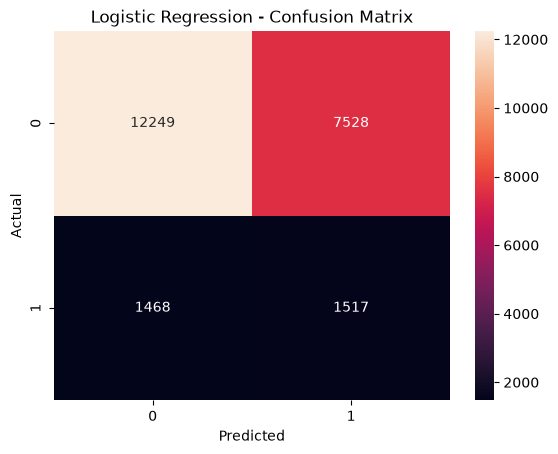

In [45]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_logistic)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

The model got many predictions right for class 0. But for class 1, some predictions were wrong. There are some predictions where model predict 1 for class 0

## DECISION TREE

In [46]:
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier(criterion='gini', random_state=42, class_weight='balanced')
tree_model.fit(X_layoff_train_scaled, y_train)
y_pred_tree = tree_model.predict(X_layoff_test_scaled)

In [47]:
print(accuracy_score(y_test, y_pred_tree))
print(precision_score(y_test, y_pred_tree, zero_division=0))
print(recall_score(y_test, y_pred_tree, zero_division=0))
print(f1_score(y_test, y_pred_tree, zero_division=0))

0.7633775590897109
0.1613540197461213
0.1916247906197655
0.17519142419601838


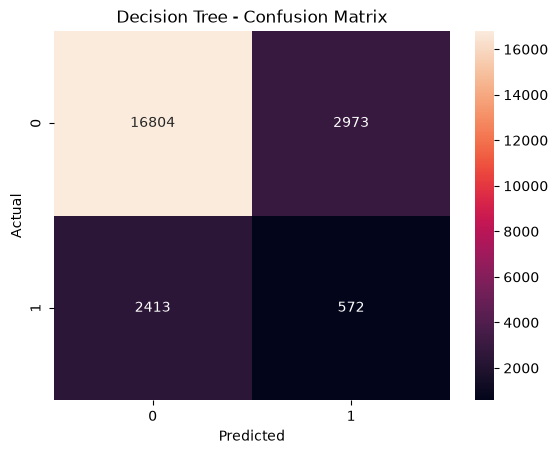

In [48]:
from sklearn.metrics import confusion_matrix
cm_tree = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm_tree, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")
plt.show()

Compared to Logistic Regression, the Decision Tree is better at predicting class 0, but it misses more class 1 cases. Logistic Regression was better at identifying class 1, while the Decision Tree has more wrong predictions for class 1.

## SVM-Linear Kernel


In [49]:
from sklearn.svm import SVC
svm_linear = SVC(kernel='linear', class_weight='balanced', max_iter=1000)
svm_linear.fit(X_layoff_train_scaled, y_train)
y_pred_svm_linear = svm_linear.predict(X_layoff_test_scaled)

c:\Users\Suhani\anaconda3\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [50]:
print(accuracy_score(y_test, y_pred_svm_linear))
print(precision_score(y_test, y_pred_svm_linear, zero_division=0))
print(recall_score(y_test, y_pred_svm_linear, zero_division=0))
print(f1_score(y_test, y_pred_svm_linear, zero_division=0))

0.5904138476408048
0.1333024762786392
0.385929648241206
0.19815945643760213


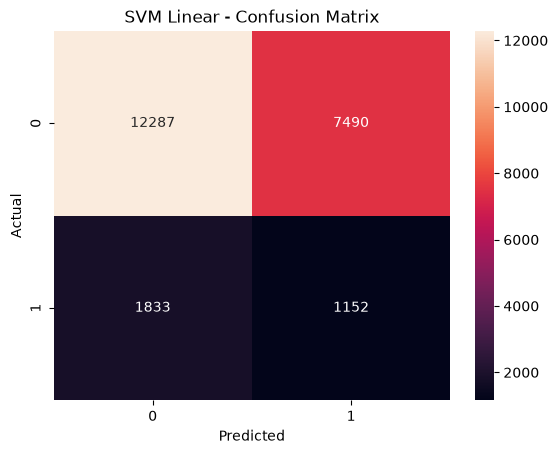

In [51]:
cm = confusion_matrix(y_test, y_pred_svm_linear)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Linear - Confusion Matrix")
plt.show()

The model correctly predicted 12,287 non-layoff and 1,152 layoff cases.
It produced 7,490 false positives and 1,833 false negatives.

## SVM - RBF Kernel

In [52]:
svm_rbf = SVC(kernel='rbf',class_weight='balanced', max_iter=5000)
svm_rbf.fit(X_layoff_train_scaled, y_train)
y_pred_svm_rbf = svm_rbf.predict(X_layoff_test_scaled)

c:\Users\Suhani\anaconda3\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [57]:
print(accuracy_score(y_test,y_pred_svm_rbf))
print(precision_score(y_test, y_pred_svm_rbf, zero_division=0))
print(recall_score(y_test, y_pred_svm_rbf, zero_division=0))
print(f1_score(y_test,y_pred_svm_rbf, zero_division=0))

0.13113961866268342
0.13113961866268342
1.0
0.2318716743698295


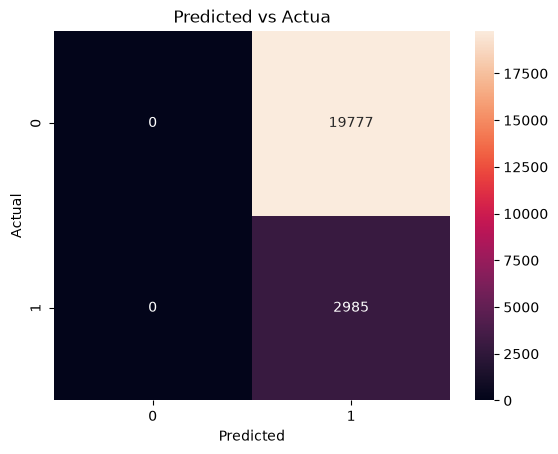

In [58]:
cm= confusion_matrix(y_test, y_pred_svm_rbf)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Predicted vs Actua")
plt.show()